# 2D Image Decomposition

Decompose 2-D image data into topologically simple basis vectors using **Top-NMF** with a cubical complex.

- **Part A** -- Hangul character images (font glyphs, 64 x 64)
- **Part B** -- Ichimatsu (checkerboard) patterns (9 x 9)

## Setup

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import torch
from urllib.request import urlretrieve

from TopNMF import (
    TopologicalNMF,
    CubicalComplex,
    target_diagram_loss,
    generate_ichimatsu_pattern,
    plot_gallery,
)
from TopNMF.visualization import FitMonitor

device = "cpu"

---
## Part A: Hangul character decomposition

### Generate Hangul character images

In [2]:
# Download the Nanum Gothic font for rendering Hangul characters
if not os.path.exists("NanumGothicCoding-Regular.ttf"):
    url = "https://github.com/google/fonts/raw/main/ofl/nanumgothiccoding/NanumGothicCoding-Regular.ttf"
    urlretrieve(url, "NanumGothicCoding-Regular.ttf")
    print("Font downloaded.")

In [3]:
def generate_hangul_images(image_size=(64, 64), font_size=48):
    """Render six Hangul characters as grayscale images."""
    try:
        base_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base_dir = os.getcwd()

    labels = ['가','다','라','갸','댜','랴']
    font_path = os.path.join(base_dir, "NanumGothicCoding-Regular.ttf")
    font = ImageFont.truetype(font_path, font_size)
    W, H = image_size
    images = []

    for ch in labels:
        img = Image.new('L', (W, H), color=0)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), ch, font=font)
        w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
        draw.text(((W - w) / 2, (H - h) / 2), ch, fill=255, font=font)
        images.append(np.array(img, dtype=np.uint8))

    return np.stack(images, axis=0), labels

images_array, labels = generate_hangul_images(font_size=48)
print(f"Generated {len(labels)} images, shape: {images_array.shape}")

Generated 6 images, shape: (6, 64, 64)


In [ ]:
# Binarize and add random intensity variation
X_hangul = (images_array > 127).astype(np.float32)
X_hangul *= np.random.uniform(low=0.5, high=1.0, size=X_hangul.shape)

n_components_hangul = 5
data_dims_hangul = X_hangul.shape[1:]  # (64, 64)

print(f"Data: {X_hangul.shape}")
plot_gallery(X_hangul, n_row=1, n_col=6)

### Fit Top-NMF

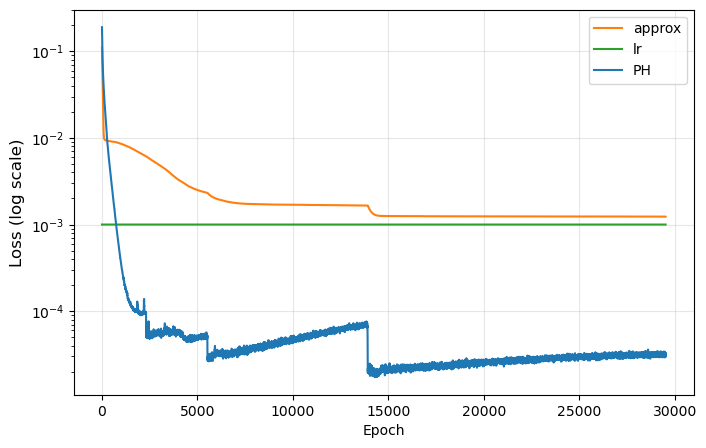

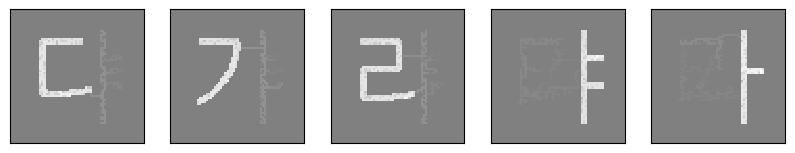

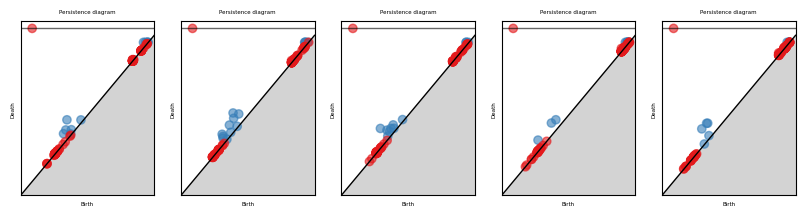

  0%|          | 0/30000 [00:00<?, ?it/s]

Final reconstruction loss: 0.0012


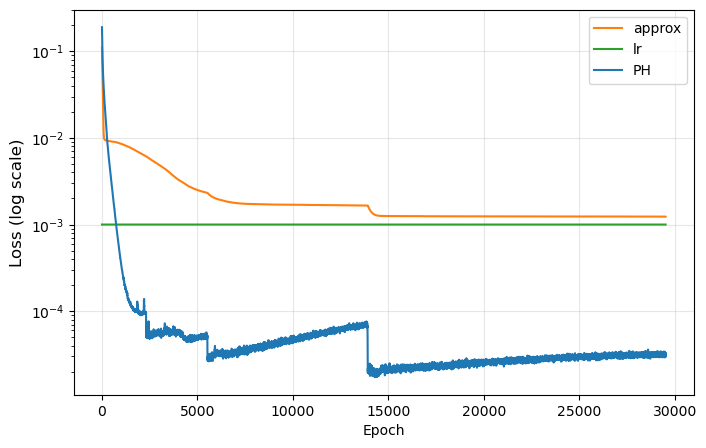

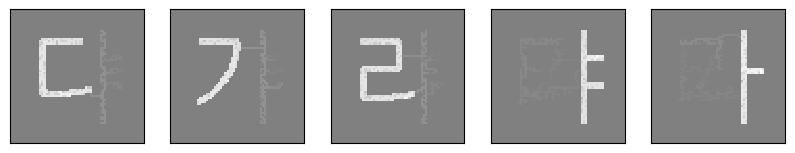

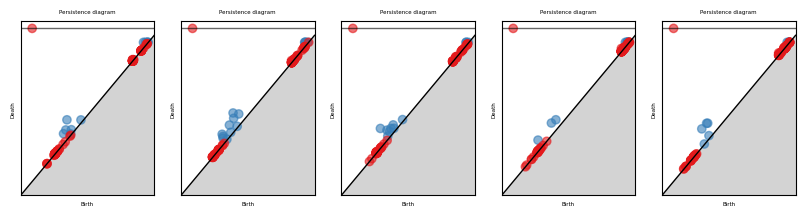

In [8]:
# Empty target diagrams encourage topologically simple bases
target_diagrams_hangul = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

# Vertex-based superlevel cubical complex for 2-D images
cubical_hangul = CubicalComplex(superlevel=True, dim=len(data_dims_hangul), mode="V")

model_hangul = TopologicalNMF(
    n_components=n_components_hangul,
    device=device,
    random_state=42,
    complex=cubical_hangul,
    ph_loss_fn=target_diagram_loss,
    data_shape=data_dims_hangul,
    use_embedding=False,
)

monitor_hangul = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=10,
    grid=(1, 5),
    PHmode="V",
    superlevel=True,
)

# Flatten spatial dims for NMF: (n_samples, n_features)
X_hangul_flat = X_hangul.reshape(X_hangul.shape[0], -1)

model_hangul.fit(
    X_hangul_flat,
    n_iterations=30000,
    lr=0.001,
    PH_dims=[0],
    lambda_top=0.7,
    weight_decay=0.2,
    verbose=True,
    target_diagrams=target_diagrams_hangul,
    init_method="nndsvda",
    monitor=monitor_hangul,
)

V_hangul = model_hangul.V.detach().cpu().numpy()
print(f"Final reconstruction loss: {model_hangul.losses['approx'][-1]:.4f}")

### Compare with standard NMF

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

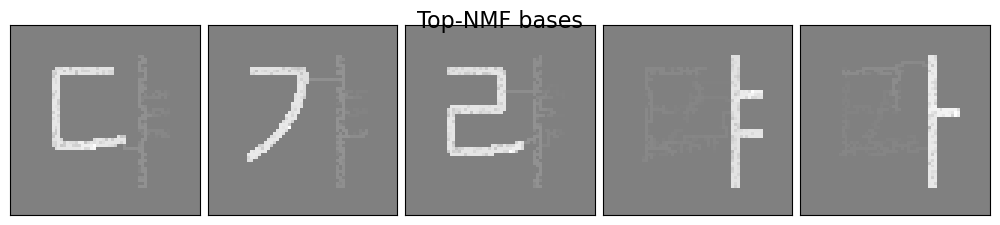

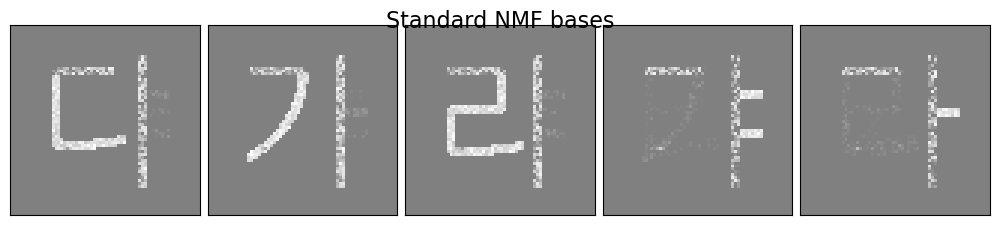

In [9]:
from sklearn.decomposition import NMF

# Top-NMF basis vectors
plot_gallery(V_hangul.reshape(-1, *data_dims_hangul), title="Top-NMF bases", n_row=1, n_col=5)

# Standard NMF for comparison
nmf = NMF(n_components=n_components_hangul, init="nndsvda", random_state=0)
nmf.fit_transform(X_hangul_flat)
H_std = nmf.components_

plot_gallery(H_std.reshape(-1, *data_dims_hangul), title="Standard NMF bases", n_row=1, n_col=5)

---
## Part B: Ichimatsu pattern decomposition

### Generate ichimatsu patterns

In [ ]:
image_shape = (9, 9)

# Define a 6x6 checkerboard kernel
pat = np.zeros((6, 6))
pat[0:2, 0:2] = 1
pat[4:6, 4:6] = 1

# Generate 40 random placements with 2-5 pattern repetitions
X_ichi = generate_ichimatsu_pattern(
    num_samples=40, image_shape=image_shape,
    pat=pat, pat_step=1, min_pat=2, max_pat=5, seed=42,
)
X_ichi /= np.max(X_ichi, axis=(1, 2), keepdims=True)  # normalise to [0, 1]

plot_gallery(X_ichi, n_row=2, n_col=8)

# Flatten to (n_samples, n_features) for NMF
X_ichi_flat = X_ichi.reshape(X_ichi.shape[0], -1)
print(f"Data: {X_ichi_flat.shape}")

### Fit Top-NMF

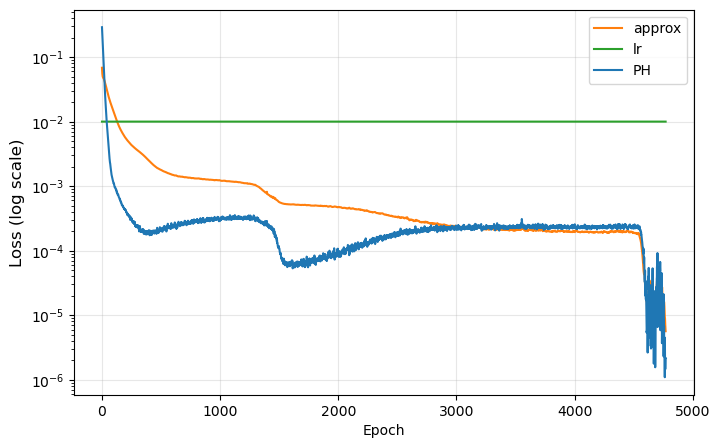

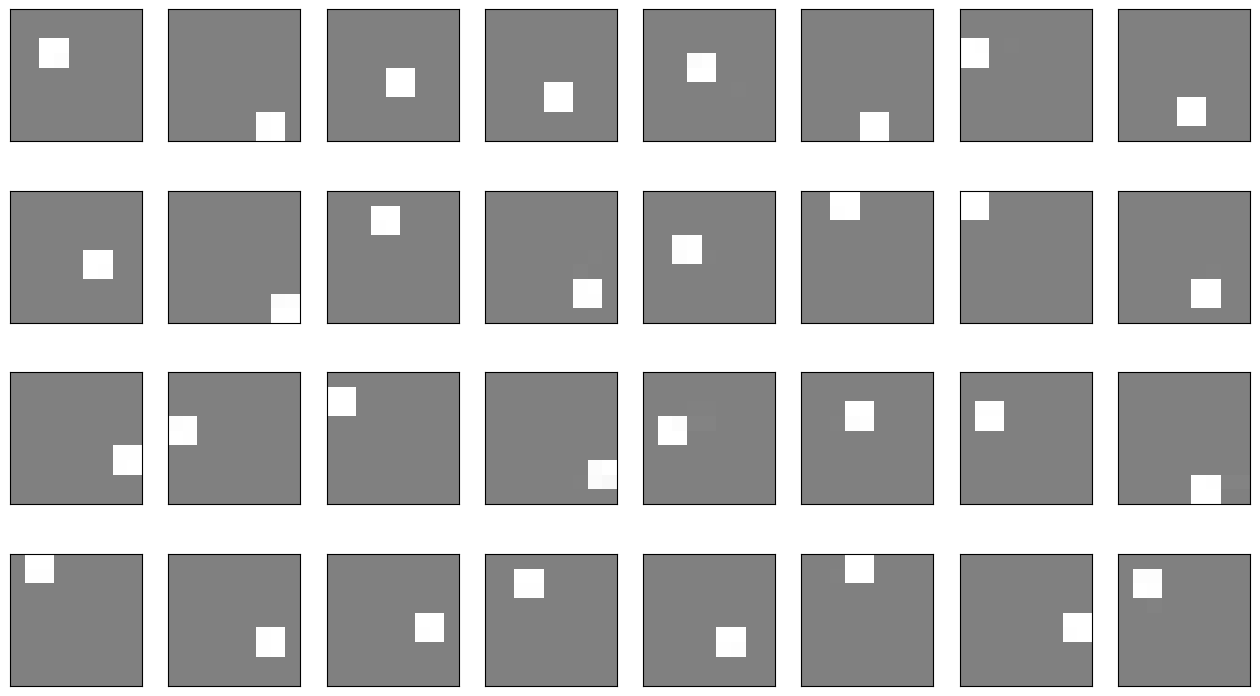

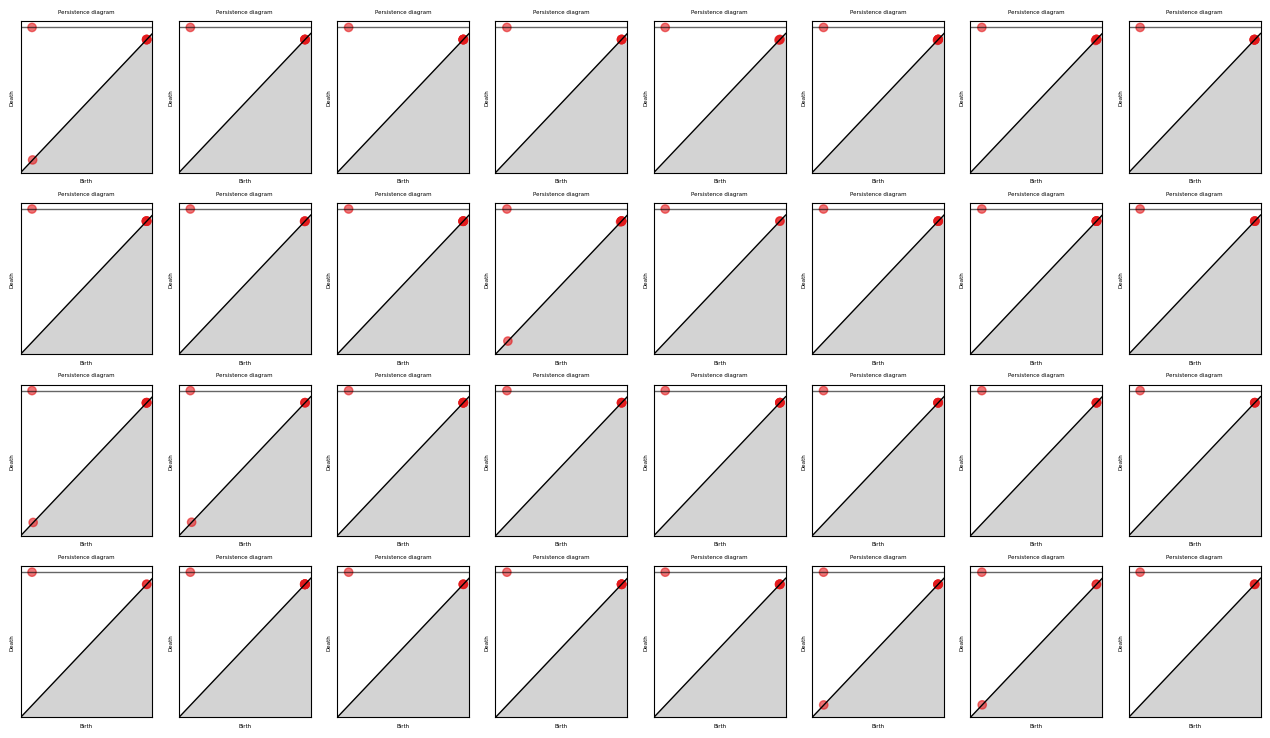

  0%|          | 0/5000 [00:00<?, ?it/s]

In [11]:
# Vertex-based superlevel cubical complex
cubical_ichi = CubicalComplex(superlevel=True, dim=len(image_shape), mode="V")

target_diagrams_ichi = [
    torch.tensor([[]], dtype=torch.float, device=device),
    torch.tensor([[]], dtype=torch.float, device=device),
]

model_ichi = TopologicalNMF(
    n_components=32,
    device=device,
    complex=cubical_ichi,
    ph_loss_fn=target_diagram_loss,
    data_shape=image_shape,
    use_embedding=False,
    random_state=42,
)

monitor_ichi = FitMonitor(
    show=["loss", "basis", "PH"],
    interval=10,
    grid=(4, 8),
    PHmode="V",
    superlevel=True,
)

model_ichi.fit(
    X_ichi_flat,
    n_iterations=5000,
    lr=0.01,
    lambda_top=0.7,
    weight_decay=0.2,
    PH_dims=[0, 1],
    start_epoch_topological=0,
    verbose=True,
    target_diagrams=target_diagrams_ichi,
    init_method="nndsvdar",
    monitor=monitor_ichi,
)

plt.close("all")

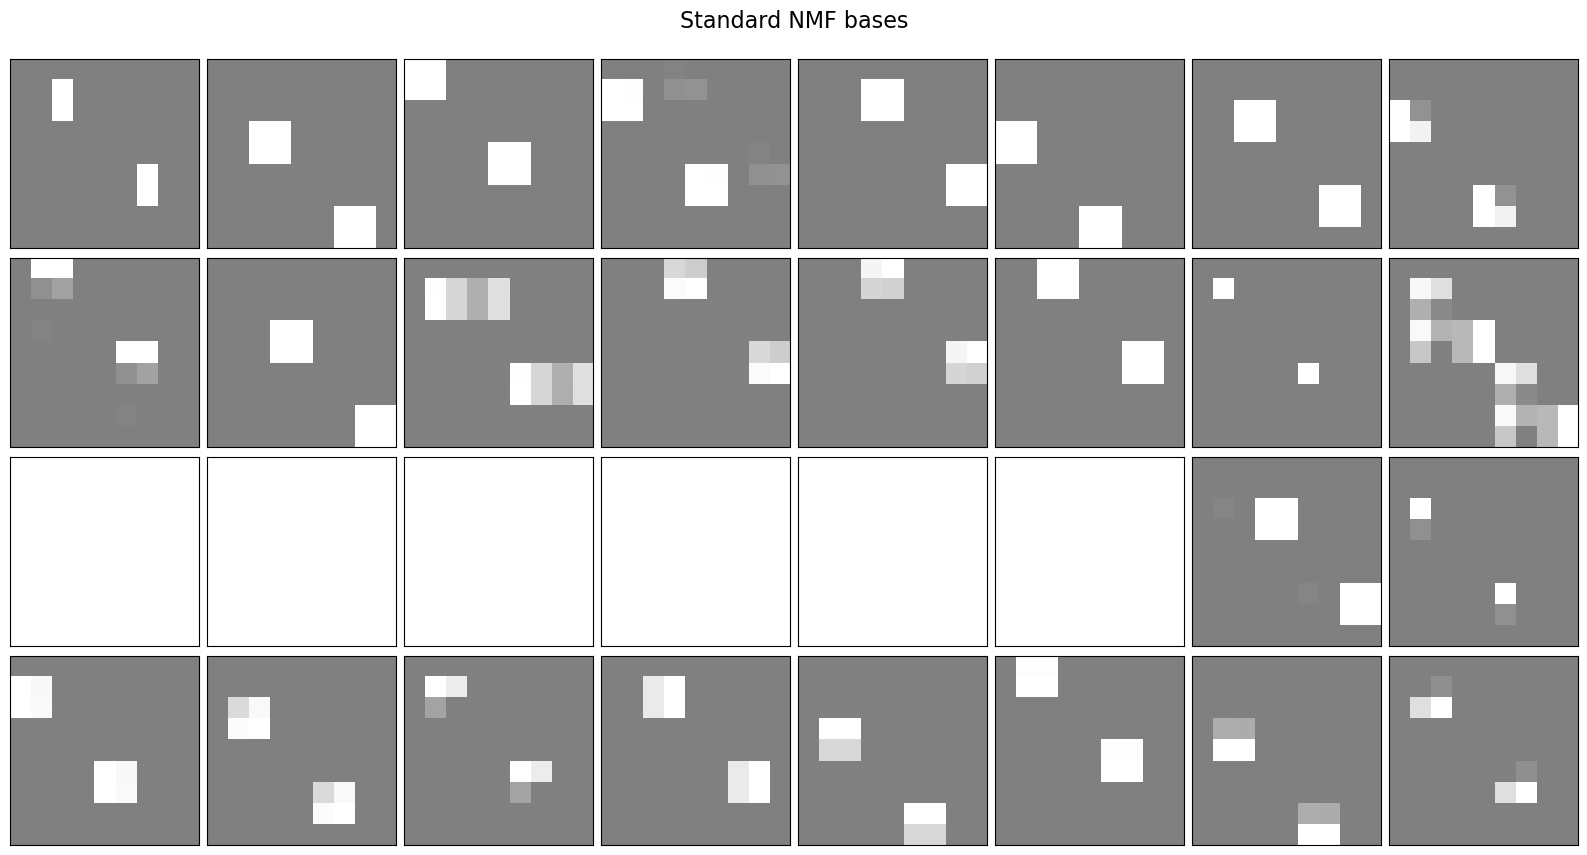

In [10]:
from sklearn.decomposition import NMF
nmf_std = NMF(n_components=32, init="nndsvda", random_state=0, max_iter=5000)
nmf_std.fit(X_ichi_flat)
basis_std = nmf_std.components_
_=plot_gallery(basis_std.reshape(-1, *image_shape), title="Standard NMF bases", n_row=4, n_col=8)